In [1]:
import os.path as op
from glob import glob 
import matplotlib.pyplot as plt
import nilearn
import nibabel as nb
import pickle
import numpy as np
import pandas as pd

In [2]:
sub_id_list = pd.read_csv('/global/homes/m/mphagen/functional-connectivity/connectome-comparison/data/2026_04_27_test_subs.txt',
                           header=None)
# test_subjects = list(test_subjects) 
sub_id_list = list(sub_id_list[0])

In [3]:
old_msmall_tspath = '/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/timeseries/old_MSMAll_FIX' 
xcpd_tspath = '/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/timeseries/xcpd' 
msmall_tspath = '/pscratch/sd/m/mphagen/human-connectome-project-openaccess/HCP1200/derivatives/timeseries/MSMAll'
fix_tspath = '/pscratch/sd/m/mphagen/human-connectome-project-openaccess/HCP1200/derivatives/timeseries/MSMAll_FIX' 

In [4]:
old_msmall_fc = '/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/connectivity-matrices/MSMAll/lassoBIC_ses' 
xcpd_fc = '/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/connectivity_matrices/xcpd/lassoBIC_ses' 
fix_fc = '/pscratch/sd/m/mphagen/human-connectome-project-openaccess/HCP1200/derivatives/connectivity-matrices/MSMAll_FIX/lassoBIC_ses' 

In [5]:
for ii in sub_id_list: 
    try: 
        with open(glob(op.join(fix_fc, f'sub-{ii}', '*pkl'))[0], 'rb') as f: 
            fix_fc_dict = pickle.load(f) 
        print(sum(sum(np.abs(fix_fc_dict['fold_0']['fc_matrix'] - fix_fc_dict['fold_1']['fc_matrix']) ) ) ) 
    except IndexError: 
        print('pass') 

    try: 
        with open(glob(op.join(old_msmall_fc, f'sub-{ii}', '*pkl'))[0], 'rb') as f: 
            old_fc_dict = pickle.load(f) 
        print(sum(sum(np.abs(old_fc_dict['fold_0']['fc_mat'] - old_fc_dict['fold_1']['fc_mat']) ) ) ) 
    except IndexError: 
        print('pass') 

    print('') 

100.86173528779182
pass

86.83997797971824
pass

112.35504289452365
pass

97.91022402895032
pass

100.89012788036052
pass

133.36609590571607
pass

104.8239670710318
pass

107.47223274696444
pass

117.27422150559141
pass

112.65706589006732
pass

137.7703427394008
206.89292332100376

131.99545464717085
203.8440120770174

117.44047599339683
162.23441491735866

141.24857426228118
183.03900572167186

130.50479837600142
189.15495246992214

95.99642233589839
165.87706693899236

83.83633050633944
136.32937733191648

113.60836913707317
176.8706058428288

118.1692537508934
174.00365139965288

89.69634998589754
136.25290015363134

111.04444833076559
151.76761795693892

90.55252982676029
136.21117433227482

94.88996092014713
139.6043368325336

123.02345542116745
188.51298491704583

102.17423838780087
144.17572442071832

117.79106712705834
181.3494331593519

111.41227564806468
201.4334806178813

121.00011192631791
192.94052829231077

88.78211120721244
138.58421535567504

94.09511443965312
145.902

In [6]:
test_sub = 'sub-342129'

In [7]:
ses_1_old_ts = nb.load(glob(op.join(old_msmall_tspath, test_sub, '*ses-1*stat-meanNORM*.nii') )[0]).get_fdata()
ses_2_old_ts = nb.load(glob(op.join(old_msmall_tspath, test_sub, '*ses-2*stat-meanNORM*.nii') )[0]).get_fdata()

In [8]:
ses_1_fix= nb.load(glob(op.join(fix_tspath, test_sub, '*ses-1*stat-meanNORM*.nii') )[0]).get_fdata()
ses_2_fix= nb.load(glob(op.join(fix_tspath, test_sub, '*ses-2*stat-meanNORM*.nii') )[0]).get_fdata()

In [9]:
ses_1_msmall = nb.load(glob(op.join(msmall_tspath, test_sub, '*ses-1*stat-meanNORM*.nii') )[0]).get_fdata()
ses_2_msmall = nb.load(glob(op.join(msmall_tspath, test_sub, '*ses-2*stat-meanNORM*.nii') )[0]).get_fdata()

In [10]:
ses_1_xcpd = nb.load(glob(op.join(xcpd_tspath, test_sub, '*ses-1*stat-mean*.nii') )[0]).get_fdata()
ses_2_xcpd = nb.load(glob(op.join(xcpd_tspath, test_sub, '*ses-2*stat-mean*.nii') )[0]).get_fdata()

In [11]:
node = 31

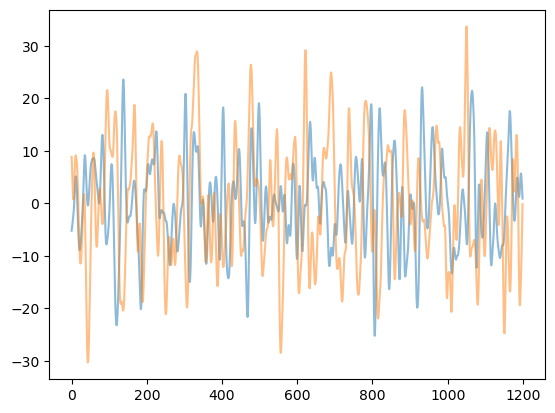

In [12]:
plt.plot(ses_2_xcpd[:, node][:1200], alpha=.5, label='fix')
plt.plot(ses_2_xcpd[:, node][1200:], alpha=.5, label='fix')


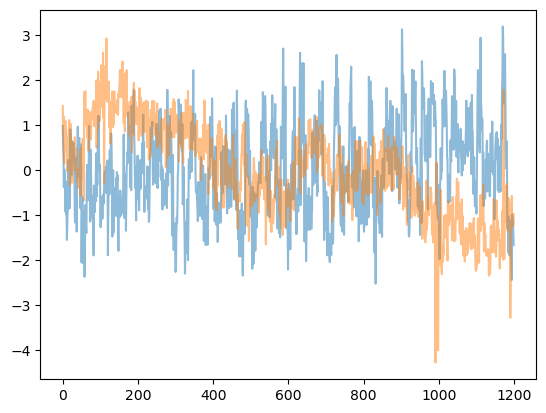

In [13]:
plt.plot(ses_1_msmall[:, node][1200:], alpha=.5, label='fix')
plt.plot(ses_2_msmall[:, node][1200:], alpha=.5, label='fix')


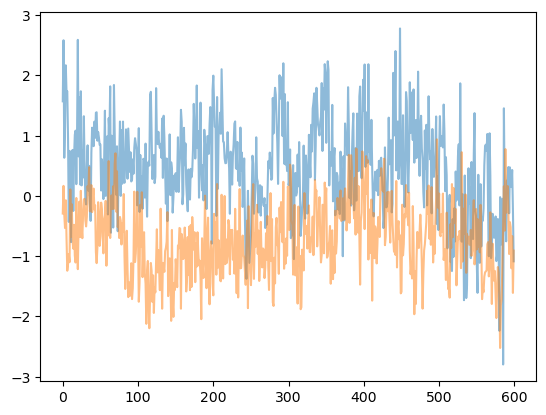

In [14]:
plt.plot(ses_1_msmall[:, node][:600], alpha=.5, label='fix')
plt.plot(ses_2_msmall[:, node][:600], alpha=.5, label='fix')


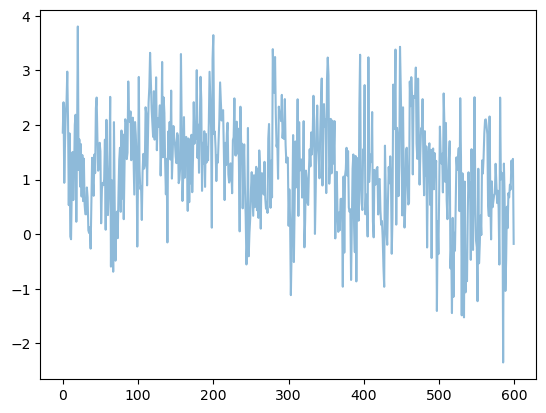

In [15]:
plt.plot(ses_1_msmall[:, node][:600] - ses_2_msmall[:, node][:600], alpha=.5, label='fix')


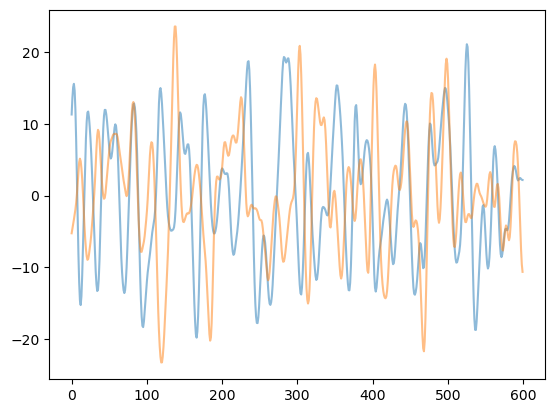

In [16]:
plt.plot(ses_1_xcpd[:, node][:600], alpha=.5, label='fix')
plt.plot(ses_2_xcpd[:, node][:600], alpha=.5, label='fix')


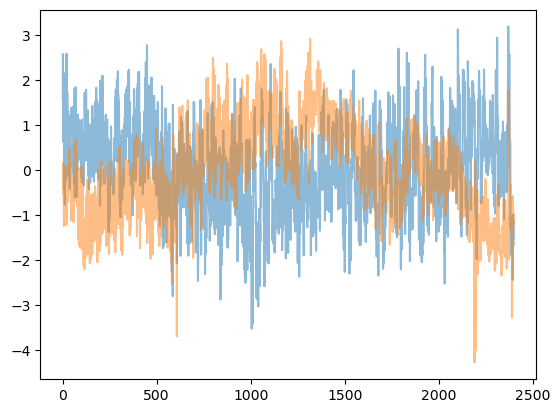

In [31]:
plt.plot(ses_1_msmall[:, node], alpha=.5, label='fix')
plt.plot(ses_2_msmall[:, node], alpha=.5, label='fix')


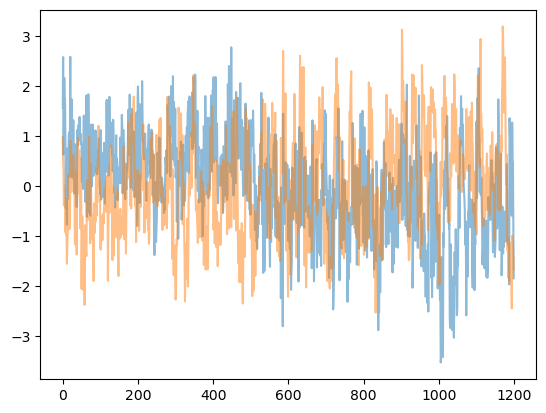

In [17]:
plt.plot(ses_1_msmall[:, node][:1200], alpha=.5, label='fix')
plt.plot(ses_1_msmall[:, node][1200:], alpha=.5, label='fix')


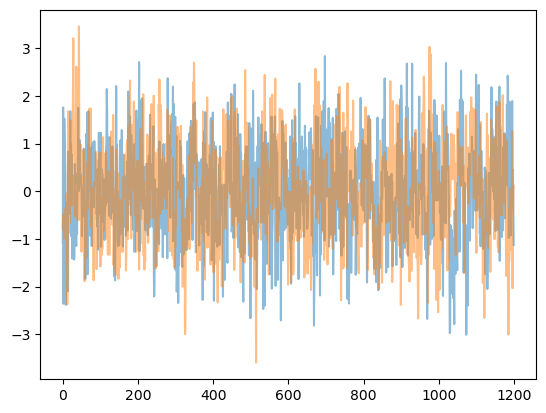

In [18]:
plt.plot(ses_1_fix[:, node][:1200], alpha=.5, label='fix')
plt.plot(ses_1_fix[:, node][1200:], alpha=.5, label='fix')


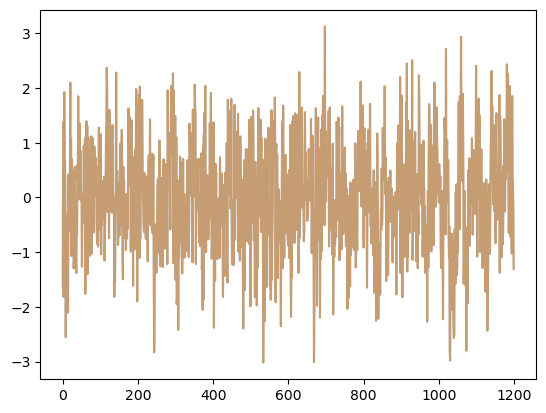

In [19]:
plt.plot(ses_1_old_ts[:, node][:1200], alpha=.5, label='fix')
plt.plot(ses_1_old_ts[:, node][1200:], alpha=.5, label='fix')


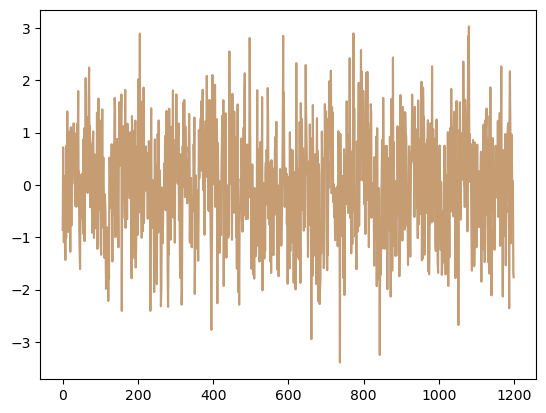

In [20]:
plt.plot(ses_2_old_ts[:, node][:1200], alpha=.5, label='fix')
plt.plot(ses_2_old_ts[:, node][1200:], alpha=.5, label='fix')


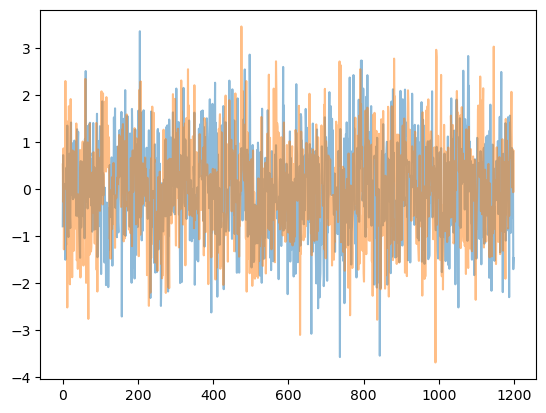

In [21]:
plt.plot(ses_2_fix[:, node][:1200], alpha=.5, label='fix')
plt.plot(ses_2_fix[:, node][1200:], alpha=.5, label='fix')


In [22]:
ses_2_fix[:, node] - ses_2_old_ts[:, node]

array([ 0.06633013,  0.00661337, -0.0869503 , ...,  0.76870133,
        1.61633176,  2.56824046], shape=(2400,))

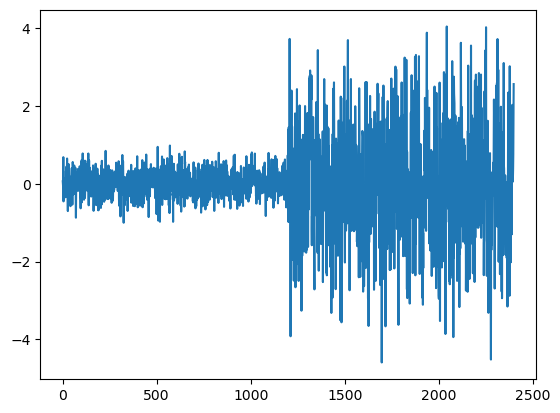

In [23]:
#there were norming differences bc of the duplication
plt.plot(ses_2_fix[:, node] - ses_2_old_ts[:, node]) 

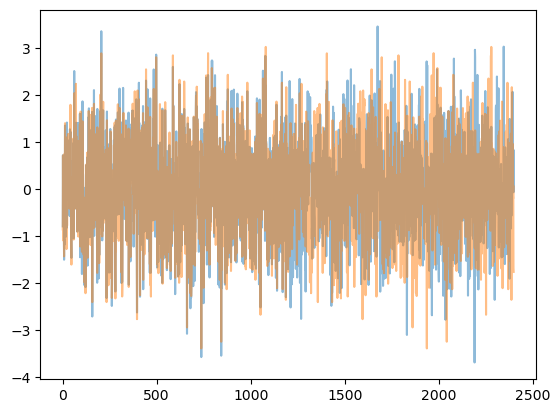

In [24]:
plt.plot(ses_2_fix[:, node], alpha=.5, label='fix')
plt.plot(ses_2_old_ts[:, node], alpha=.5)

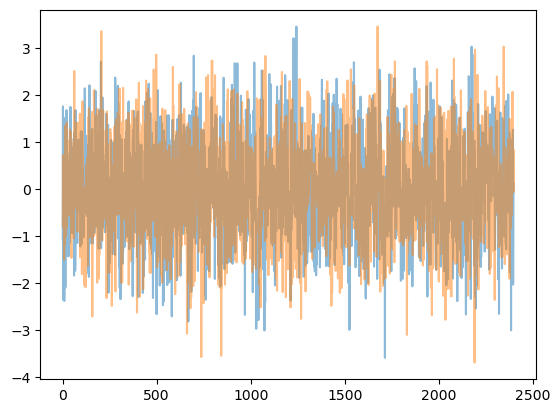

In [29]:
plt.plot(ses_1_fix[:, node], alpha=.5, label='fix')
plt.plot(ses_2_fix[:, node], alpha=.5)

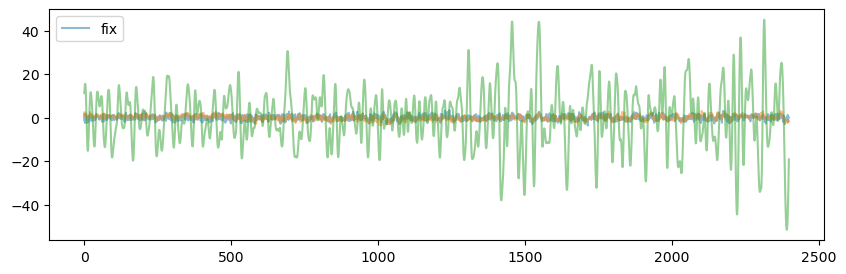

In [26]:
plt.subplots(1,1, figsize=(10,3))  
plt.plot(ses_1_fix[:, node], alpha=.5, label='fix')
plt.plot(ses_1_msmall[:, node], alpha=.5)
plt.plot(ses_1_xcpd[:, node], alpha=.5)

plt.legend() 

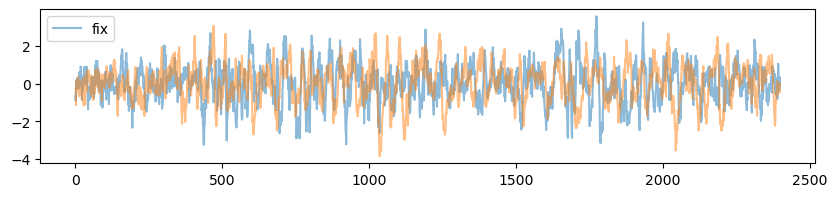

In [28]:
plt.subplots(1,1, figsize=(10,2))  
plt.plot(ses_2_fix[:, 3], alpha=.5, label='fix')
plt.plot(ses_1_fix[:, 3], alpha=.5)
plt.legend() 